---
title: "Chapter 1: From Data to a First Model"
---

::: {.callout-lo} 

By the end of this chapter, you should be able to:

- Define examples, features, targets, predictions, training, and error;
- Represent a supervised learning problem with $X$ and $y$;
- Distinguish classification from regression
- Use the `scikit-learn` `fit`–`predict`–`score` workflow;
- Build a simple baseline and explain why it matters;
- Explain how a decision tree learns rules and makes predictions;
- Distinguish model parameters from hyperparameters; and
- Interpret tree depth and decision boundaries as measures of model complexity.

:::

You already know how to write a program that follows rules. Suppose, however, that you want to predict a student's quiz result from attendance and previous grades. What rules should the program use, and how would you choose them? Instead of specifying every rule ourselves, we can use examples with known outcomes to learn a prediction rule from data.

This is **supervised learning**: each training example has a known target, and the goal is to predict that target for new examples. In **unsupervised learning**, there is no designated target; instead, we look for structure in the data, such as customers with similar tastes or habits.

In this chapter, we will turn the quiz prediction problem into a feature table and target, establish a simple reference prediction, and then use a decision tree to learn rules that use the features. Along the way, we will learn the `scikit-learn` workflow and explore how much detail a tree can capture. We will end with a question that motivates Chapter 2: how can we tell whether those rules will work for new students?

**Imports**

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("code"))

import mglearn
from IPython.display import HTML, display
from plotting_functions import *
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from utils import *

plt.rcParams["font.size"] = 16
pd.set_option("display.max_colwidth", 200)

%matplotlib inline

DATA_DIR = Path("data")

## Core terminology

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/YNT8n4cXu4A) introduces the terminology used in this section.
:::

### Running example: quiz-grade prediction

For our first model, imagine that students want to anticipate whether they will receive an A+ on Quiz 2. They collect data from a previous offering containing attendance, lab grades, Quiz 1 performance, and the eventual Quiz 2 result.

::: {.callout-reflection}
<div class="callout-reflection-title">Pause and reflect</div>

Before looking at the data, consider two questions: What do you want to predict? What information could be useful for making that prediction?
:::

We will use two small datasets in this and the next chapter:

- [Quiz 2 classification data](data/quiz2-grade-toy-classification.csv)
- [Quiz 2 regression data](data/quiz2-grade-toy-regression.csv)

These deliberately small datasets let us inspect every step. Later chapters use larger, messier datasets.

The classification version asks whether a student will receive an A+ rather than predicting the exact grade. Each row describes one student from a previous offering.

In [2]:
classification_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-classification.csv")
print(classification_df.shape)
classification_df.head()

(21, 8)


,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+


### Examples, features, and targets

A supervised learning dataset contains examples for which the outcome is known. Each row is an **example**, the input columns are **features**, and the column we want to predict is the **target**. A learning algorithm uses these examples to construct a model that can make predictions for new cases.

![](img/sup-ml-terminology.png)

The table may look familiar from data analysis. The new step is to assign each column a role in a prediction task. A column is not inherently a feature or a target: that depends on what we want to predict and what information will be available when we make the prediction.

**Feature**
: An input characteristic available to the model. The feature table is conventionally denoted by $X$, and the number of features by $d$.

**Target**
: The outcome we want to predict, conventionally denoted by $y$.

**Example**
: One observation, represented by a row of feature values. The number of examples is conventionally denoted by $n$.

**Training**
: The process through which a learning algorithm uses $X$ and $y$ to determine a model's parameters. Training is also called *fitting*.

#### Separating the feature table and target

In [3]:
classification_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-classification.csv")
classification_df.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+


Before fitting a supervised model, we separate the feature table `X` from the target vector `y`. Keeping this distinction explicit helps prevent the answer from accidentally becoming an input to the model.

In [4]:
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]
X.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1
0,1,1,92,93,84,91,92
1,1,0,94,90,80,83,91
2,0,0,78,85,83,80,80
3,0,1,91,94,92,91,89
4,0,1,77,83,90,92,85


In [5]:
y.head()

0        A+
1    not A+
2    not A+
3        A+
4        A+
Name: quiz2, dtype: str

#### A second example: housing-price prediction

The same representation applies when the target is numerical. Here, each row represents a house, the property attributes form `X`, and price is `y`.

In [6]:
housing_df = pd.read_csv(DATA_DIR / "kc_house_data.csv")
housing_df.drop(columns = ["id", "date"])
housing_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
X = housing_df.drop(columns=["price"])
y = housing_df["price"]
X.head()

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [8]:
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

In [9]:
X.shape

(21613, 20)

::: {.callout-important}
Column names are meaningful to people, but most models operate on the feature values. A descriptive name does not make a feature informative, and an ambiguous name does not prevent its values from influencing a model.
:::

### Terminology across disciplines

Different communities often use different words for the same role:

- **examples** = rows = samples = records = instances;
- **features** = inputs = predictors = explanatory variables = covariates;
- **targets** = outputs = outcomes = responses; categorical targets are often called labels; and
- **training** = learning = fitting.

The surrounding context determines which meaning is intended.

::: {.callout-tip title="See also"}
The [MDS terminology guide](https://ubc-mds.github.io/resources_pages/terminology/) provides a broader cross-disciplinary glossary.
:::

### Classification and regression

Supervised problems are commonly distinguished by the kind of target:

- **Classification** predicts one of two or more discrete classes. For example, liver disease versus no liver disease, or A+ versus not A+.
- **Regression** predicts a numerical quantity. For example, a house price or percentage grade.

The distinction affects which models and evaluation measures are appropriate.

The question determines the task, even when we start from the same records. Predicting a student's percentage grade is regression; predicting whether that grade reaches the A+ threshold is classification. A numerical class code, such as `0` for not A+ and `1` for A+, still represents a classification target.

![](img/classification-vs-regression.png)

<!-- <img src="img/classification-vs-regression.png" height="1500" width="1500">  -->

In [10]:
# quiz2 classification toy data
classification_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-classification.csv")
classification_df

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+
5,1,0,70,73,68,74,71,not A+
6,1,0,80,88,89,88,91,A+
7,0,1,95,93,69,79,75,not A+
8,0,0,97,90,94,99,80,not A+
9,1,1,95,95,94,94,85,not A+


In [11]:
# quiz2 regression toy data
regression_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-regression.csv")
regression_df

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,90
1,1,0,94,90,80,83,91,84
2,0,0,78,85,83,80,80,82
3,0,1,91,94,92,91,89,92
4,0,1,77,83,90,92,85,90
5,1,0,70,73,68,74,71,75
6,1,0,80,88,89,88,91,91


### Prediction and statistical inference

**Prediction** asks about the outcome for a new or unseen example. 

**Statistical inference** asks what we can learn about a population or relationships from the data we have observed, often including how uncertain we are about those conclusions. The table below shows examples of prediction and inference problems in different domains: 

| Context | Prediction | Statistical inference |
|---|---|---|
| Health | How long will this patient take to recover? | What is the average recovery time in the population? |
| Education | Is this student likely to pass the course? | Is course performance associated with attendance? |
| Housing | What will this house sell for? | How are house prices related to square footage? |

Prediction and statistical inference can complement one another, but good predictive performance does not necessarily mean that we can draw reliable conclusions about the underlying population or relationships between variables. 

:::{.callout-tip title="Note"} 

In deployed machine-learning systems, the word inference is also sometimes used for the act of generating predictions with an already-fitted model; that operational usage is distinct from statistical inference.
:::

::: {.callout-question}

<div class="exercise-title">Exercise 1.1: Supervised or unsupervised?</div>

Select all examples of supervised learning.

- (A) Finding groups of similar properties in a real-estate dataset.
- (B) Predicting heart-attack risk from demographic, dietary, and clinical measurements.
- (C) Grouping news articles by topic.
- (D) Detecting credit-card fraud from labeled fraudulent and non-fraudulent transactions.
- (E) Using measured employee performance to investigate which recorded factors predict it.

:::

::: {.callout-tip collapse="true" title="Solution"}
B, D, and E are supervised because each requires an observed target. E emphasizes interpretation, so predictive associations should not automatically be treated as causal effects.
:::

::: {.callout-question}

<div class="exercise-title">Exercise 1.2: Classification or regression?</div>

Select all regression problems.

- (A) Predicting the price of a house.
- (B) Predicting whether a house will sell.
- (C) Predicting a student's percentage grade.
- (D) Predicting whether to bicycle tomorrow.
- (E) Predicting an appropriate numerical thermostat setting.

:::

::: {.callout-tip collapse="true" title="Solution"}
A, C, and E have numerical targets and are therefore regression problems.
:::

::: {.callout-question}

<div class="exercise-title">Exercise 1.3: Define the representation</div>

For each problem below, identify one possible unit of analysis, a target, and several features that would be available at prediction time:

1. sentiment analysis;
2. fraud detection; and
3. face recognition.

Are any of the proposed features ethically sensitive, unavailable at prediction time, or likely to encode the target indirectly?

:::

## Establishing a baseline

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/6eT5cLL-2Vc) develops the baseline example in this section.
:::

We have defined what we want to predict and separated the inputs from the target. Before learning rules from those inputs, we need a way to judge whether a model's predictions are useful. An accuracy value alone is hard to interpret: if one outcome is common, a model can get many answers right simply by always choosing it.

Let's first inspect how often each quiz-grade outcome occurs.

In [12]:
classification_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-classification.csv")
classification_df.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+


In [13]:
classification_df["quiz2"].value_counts()

quiz2
not A+    11
A+        10
Name: count, dtype: int64

The label “not A+” is more common. A strategy that always predicts this majority class ignores every feature, but it may still achieve substantial accuracy. That makes it a useful sanity check.

### Why start with a baseline?

**Baseline**
: A simple reference strategy against which more elaborate models can be compared.

For classification, a common baseline always predicts the most frequent training label. A useful learned model should improve on an appropriate baseline in a way that matters for the problem.

Start with this baseline when building a classifier: it shows what can be achieved using only the class frequencies. It does not tell us which individual students will receive an A+, because it makes the same prediction for everyone. That limitation will motivate a model that uses the features.

### A classification baseline with `DummyClassifier`

Throughout the supervised-learning chapters, we will use the Python library `scikit-learn` as our primary framework for building and evaluating models. It provides a consistent interface for many different models, including `DummyClassifier` for simple classification baselines. We will begin by fitting a most-frequent baseline to the quiz-grade data.

### The `scikit-learn` `fit–predict–score` workflow

We will implement the baseline one step at a time, then reuse the same pattern for a decision tree. In `scikit-learn`, model objects are formally called **estimators**. Most supervised models follow the same interface:

1. construct the feature table `X` and target `y`;
2. create a model;
3. call `fit(X, y)` to learn from the training data;
4. call `predict(X_new)` to predict new examples; and
5. evaluate predictions with an appropriate measure.

Fitting requires known targets so the model can learn from examples. Prediction uses only the features: the target is the answer we are trying to obtain.

#### Reading the data

In [14]:
classification_df.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+


#### Create $X$ and $y$

Use the input columns as `X` and the quiz outcome as `y`. The target must stay out of the feature table; it will not be available for a new student whose outcome we want to predict.

In [15]:
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]

#### Create a classifier object

Import the estimator and create an object with the desired baseline strategy. At this point, the object has not yet seen our data.

In [16]:
from sklearn.dummy import DummyClassifier  # import the classifier

dummy_clf = DummyClassifier(strategy="most_frequent")  # Create a classifier object

#### `fit` the classifier

Calling `fit` learns from the supplied data. For this baseline, learning consists of identifying the most frequent target class; it does not learn relationships between features and the target.

In [17]:
dummy_clf.fit(X, y)
# fit the classifier

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.48,0.52]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](2,)","['A+','not A+']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](7,)","['ml_experience','class_attendance','lab1',...,'lab3','lab4','quiz1']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,7
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


#### `predict` the target of given examples

Calling `predict` uses the fitted model. Here every example receives the same prediction, regardless of its feature values.

In [18]:
dummy_clf.predict(X)  # predict using the trained classifier

array(['not A+', 'not A+', 'not A+', 'not A+', 'not A+', 'not A+',
       'not A+', 'not A+', 'not A+', 'not A+', 'not A+', 'not A+',
       'not A+', 'not A+', 'not A+', 'not A+', 'not A+', 'not A+',
       'not A+', 'not A+', 'not A+'], dtype='<U6')

#### Evaluating with `score`

A model's `score` method provides a convenient default measure, but its meaning depends on the model. For classifiers it is usually accuracy—the proportion of correctly predicted targets:

$$\text{accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

Always check what `score` returns before interpreting it as model quality.

In [19]:
print("The accuracy of the model on the training data: %0.3f" % (dummy_clf.score(X, y)))

The accuracy of the model on the training data: 0.524


Classification **error** is often defined as $1 - \text{accuracy}$. Calling a classifier's `score(X, y)` typically runs `predict(X)`, compares the predictions with `y`, and returns accuracy.

The baseline's training accuracy is the fraction of students in the majority class. It has achieved this score without using attendance or grades, so a model with the same accuracy has not yet demonstrated a benefit from those inputs.

For now we evaluate on the same small dataset used for fitting. This demonstrates the API, but it does **not** tell us how well the model will work on new data. Chapter 2 addresses that central problem.

In [20]:
print(
    "The error of the model on the training data: %0.3f" % (1 - dummy_clf.score(X, y))
)

The error of the model on the training data: 0.476


#### The `fit`, `predict`, and `score` pattern

The complete baseline workflow is shown below.

In [21]:
# Create `X` and `y` from the given data
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]

clf = DummyClassifier(strategy="most_frequent")  # Create a class object
clf.fit(X, y)  # Train/fit the model
print(clf.score(X, y))  # Assess the model

new_examples = [[0, 1, 92, 90, 95, 93, 92], [1, 1, 92, 93, 94, 92]]
clf.predict(new_examples)  # Predict on some new data using the trained model

0.5238095238095238


array(['not A+', 'not A+'], dtype='<U6')

::: {.callout-note}
You will investigate classification baselines more fully in the exercises and lab.
:::

### A regression baseline with `DummyRegressor`

What changes if we want to predict the percentage grade instead of an A+ label? There is no majority class to predict, but we can still give every student the same numerical prediction. `DummyRegressor` can use a constant such as the training-set mean or median. The mean gives a simple starting point; like the classification baseline, it ignores differences between students.

The workflow stays the same, but accuracy is no longer an appropriate default: a predicted grade can be close to the observed grade without matching it exactly. The default `score` for `DummyRegressor` is $R^2$, introduced below.

The code below applies the same `fit` and `predict` pattern to the numerical version of the quiz-grade problem.

In [22]:
from sklearn.dummy import DummyRegressor

regression_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-regression.csv")  # Read data
X = regression_df.drop(columns=["quiz2"])  # Create `X` and `y` from the given data
y = regression_df["quiz2"]
reg = DummyRegressor()  # Create a class object
reg.fit(X, y)  # Train/fit the model
reg.score(X, y)  # Assess the model
new_examples = [[0, 1, 92, 90, 95, 93, 92], [1, 1, 92, 93, 94, 92]]
reg.predict(new_examples)  # Predict on some new data using the trained model

array([86.28571429, 86.28571429])

`fit` and `predict` play the same roles for regression and classification, but the default score differs. For regressors, `score` normally returns [$R^2$](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html):

- $R^2=1$ represents perfect predictions;
- a mean-prediction baseline usually has $R^2=0$ on the data used to evaluate that mean; and
- $R^2<0$ means the predictions are worse than predicting that mean.

We study regression evaluation measures in detail later in the book.

In [23]:
reg.score(X, y)

0.0

::: {.callout-question}

<div class="exercise-title">Exercise 1.4: What does the baseline tell us?</div>

A dataset contains 80 not-A+ outcomes and 20 A+ outcomes. A most-frequent `DummyClassifier` is fitted and scored on these 100 examples.

1. What are its accuracy and error? How many of the A+ outcomes does it predict correctly?
2. A classmate says, “It gets 80% right, so it must have learned useful relationships between grades and outcomes.” Explain the mistake.
3. If you change every student's attendance value but keep the targets unchanged, will this baseline's predictions change? Why?

:::

::: {.callout-tip collapse="true" title="Solution"}
Its accuracy is 0.80 and its error is 0.20. It predicts not A+ for everyone, so it correctly identifies none of the A+ outcomes. The score comes entirely from how common not A+ is, rather than from relationships with the features. Changing attendance does not change this baseline's predictions because it ignores feature values.
:::

## Learning rules with decision trees

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/Hcf19Ij35rA) introduces decision trees.
:::

### From hand-written rules to learned rules

Can we do better than the majority-class baseline? One option is to write nested `if`/`else` rules using attendance and previous grades. To make the idea easy to visualize, first imagine that the feature values have been converted to binary indicators.

![](img/quiz2-grade-toy.png)

Look for combinations that distinguish A+ from not A+. A hand-written program might begin like this:

```python
if class_attendance == 1 and quiz1 == 1:
    prediction = "A+"
elif class_attendance == 1 and lab3 == 1 and lab4 == 1:
    prediction = "A+"
else:
    prediction = "not A+"
```

Even with seven binary features, there are many possible combinations. We would have to decide which features to check, in what order, and what to predict when the evidence conflicts. Rules chosen by inspection also become harder to maintain as the dataset grows.

A decision tree learns a hierarchy of these questions from examples rather than requiring us to enumerate the rules by hand.

::: {.callout-reflection}
<div class="callout-reflection-title">Pause and reflect</div>

Before fitting one, inspect the examples above: which single yes/no question seems most effective at separating A+ from not A+? A useful question creates groups whose outcomes are more homogeneous than the original group.
:::

### The decision-tree intuition

A decision tree resembles the [Twenty Questions](https://en.wikipedia.org/wiki/Twenty_questions) game. At each node it asks a question about one feature and follows a branch based on the answer. Training determines which questions to ask; prediction follows the learned path to an answer.

### Building decision trees with `sklearn`

Let's binarize our toy dataset for simplicity. 

In [24]:
classification_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-classification.csv")
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]

X_binary = X.copy()
columns = ["lab1", "lab2", "lab3", "lab4", "quiz1"]
for col in columns:
    X_binary[col] = X_binary[col].apply(lambda x: 1 if x >= 90 else 0)
X_binary.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1
0,1,1,1,1,0,1,1
1,1,0,1,1,0,0,1
2,0,0,0,0,0,0,0
3,0,1,1,1,1,1,0
4,0,1,0,0,1,1,0


In [25]:
y.head()

0        A+
1    not A+
2    not A+
3        A+
4        A+
Name: quiz2, dtype: str

#### `DummyClassifier` on quiz2 grade prediction toy dataset 

In [26]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_binary, y)
dummy_clf.score(X_binary, y)

0.5238095238095238

#### `DecisionTreeClassifier` on quiz2 grade prediction toy dataset 

In [27]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=123)  # Create a reproducible decision tree
model.fit(X_binary, y)  # Fit a decision tree
model.score(X_binary, y)  # Assess the model

0.9047619047619048

The decision tree has much higher **training accuracy** than the dummy baseline. That is encouraging, but it does not yet establish that the tree will predict new students well. We will return to this distinction at the end of the chapter.

::: {.callout-note}
The following visualization uses `custom_plot_tree`, a supporting plotting function from `book/code/`. Keeping this helper separate lets us focus here on interpreting the model, while its implementation remains available for inspection and reuse.
:::

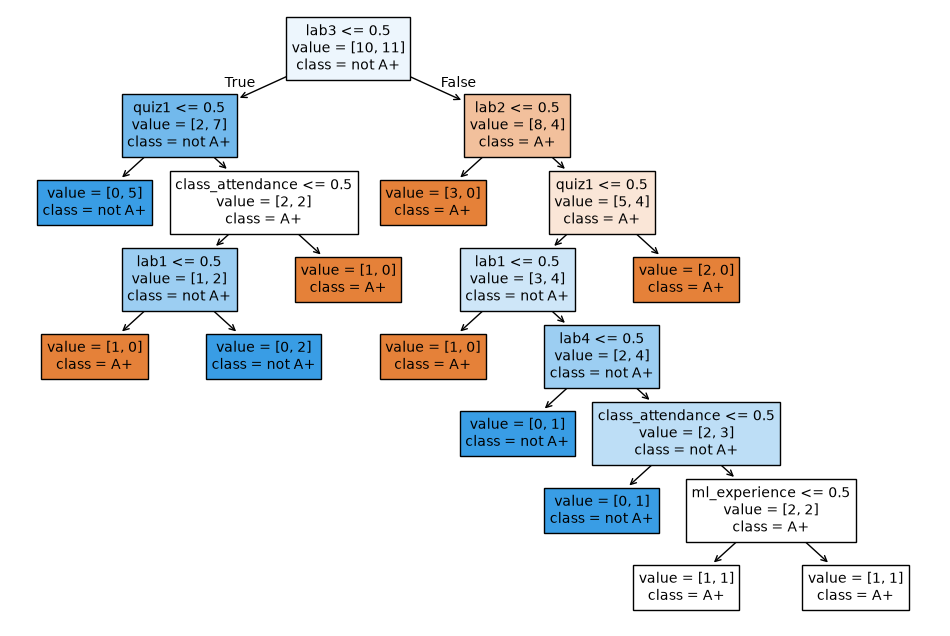

In [28]:
# Call the custom_plot_tree function to visualize the customized tree
width = 12
height = 8
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=10,
)

### Reading a decision tree

**Root node**
: The first question asked by the tree.

**Branch**
: A connection representing the result of a question.

**Internal node**
: A subsequent question within the tree.

**Leaf node**
: The prediction produced after following a path through the tree.

**Tree depth**
: The number of edges on the longest path from the root to a leaf.

### How does prediction work?

In [29]:
new_example = pd.DataFrame([[0, 1, 0, 0, 1, 1, 1]], columns=X.columns)
new_example

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1
0,0,1,0,0,1,1,1


What's the prediction for the new example?

In [30]:
model.predict(new_example)

array(['A+'], dtype=object)

To predict for a new example, begin at the root, answer the question at each node, and follow the corresponding branch. The leaf at the end of the path gives the prediction. Features that do not appear along that path do not affect that prediction. For the new example above, the path is:

`lab3 <= 0.5` is **False** $\rightarrow$ follow the right branch $\rightarrow$ `lab2 <= 0.5` is **True** $\rightarrow$ follow the left branch $\rightarrow$ predict **A+**.

### How does fitting work conceptually?

Prediction follows questions that have already been chosen. Fitting must choose those questions from the training data. At each node, the algorithm compares candidate feature-and-threshold questions and selects a split that makes the resulting groups more homogeneous in their targets. It then repeats this process within the resulting groups, subject to stopping conditions.

This is a sequence of local choices: the algorithm does not try every complete tree and select the best one. To see what makes one question more useful than another, let's compare a few possible first splits.

### Choosing splits

To build intuition, consider three possible questions at the root of our toy tree:

- Splitting on `ml_experience` is not very useful: students without ML experience include 5 A+ and 5 not-A+ outcomes, while students with ML experience include 5 A+ and 6 not-A+ outcomes. The two groups have almost the same class mixture.
- Splitting on whether `lab3 >= 90` is more useful: the below-90 group contains 2 A+ and 7 not-A+ outcomes, while the at-least-90 group contains 8 A+ and 4 not-A+ outcomes.
- `class_attendance` provides a similar separation: the group that did not attend contains 2 A+ and 6 not-A+ outcomes, while the group that attended contains 8 A+ and 5 not-A+ outcomes.

The latter questions produce groups whose outcomes are more homogeneous than the original group. At each node, a classification tree quantifies this idea by comparing candidate questions using a measure of class impurity, such as the [Gini index or entropy](https://scikit-learn.org/stable/modules/tree.html#classification-criteria). The exact search and optimization details are beyond the scope of this course, but the result is a hierarchy of data-derived rules.

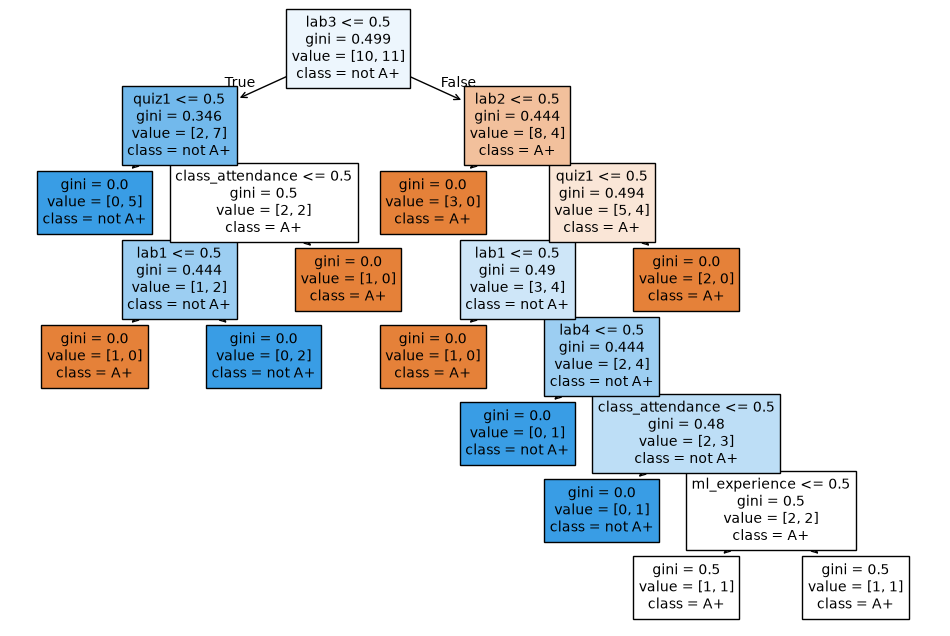

In [31]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=123)  # Create a reproducible decision tree
model.fit(X_binary, y)  # Fit a decision tree
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    fontsize=10,
)

::: {.callout-note}
Decision trees can split both categorical representations and numerical features. For a numerical feature, fitting also learns a threshold such as `quiz1 <= 88.5`.
:::

### Trees with numerical features

In [32]:
X.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1
0,1,1,92,93,84,91,92
1,1,0,94,90,80,83,91
2,0,0,78,85,83,80,80
3,0,1,91,94,92,91,89
4,0,1,77,83,90,92,85


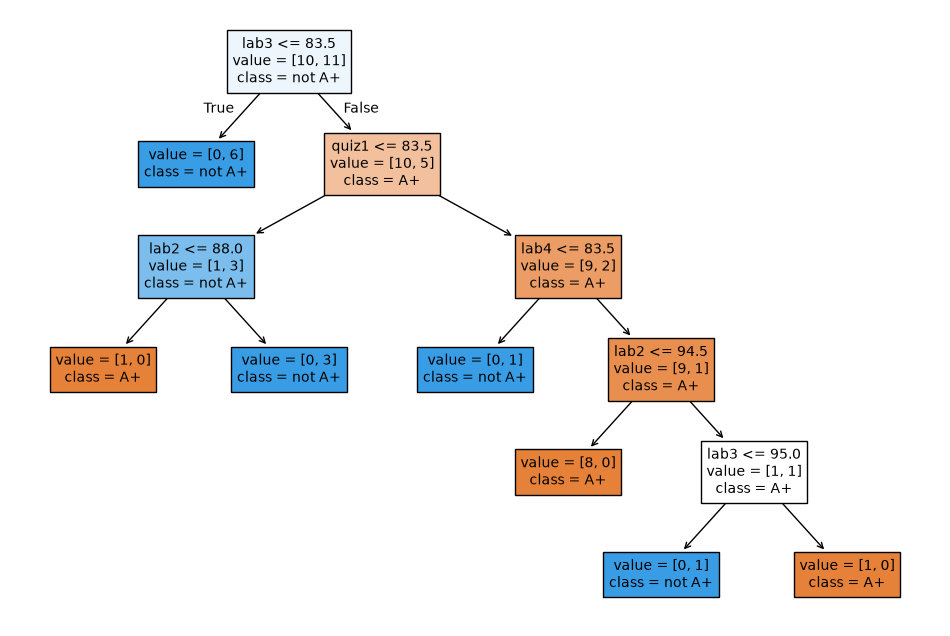

In [33]:
model = DecisionTreeClassifier(random_state=123)
model.fit(X, y)
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=10,
)

### Decision trees for regression

Decision trees can also predict numerical targets. A `DecisionTreeRegressor` uses the same `fit` and `predict` interface, but chooses splits using a regression criterion such as squared error. Its default `score` is $R^2$, which can be negative when predictions are worse than the mean baseline.

At prediction time, a regression tree still routes an example to a leaf. With the default squared-error criterion, the prediction is the mean target of the training examples in that leaf. Students reaching the same leaf therefore receive the same predicted grade, even if their feature values differ.

In [34]:
regression_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-regression.csv")
regression_df.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,90
1,1,0,94,90,80,83,91,84
2,0,0,78,85,83,80,80,82
3,0,1,91,94,92,91,89,92
4,0,1,77,83,90,92,85,90


In [35]:
X = regression_df.drop(columns = ["quiz2"])
y = regression_df["quiz2"]

depth = 2
reg_model = DecisionTreeRegressor(max_depth=depth)
reg_model.fit(X, y)
regression_df["predicted_quiz2"] = reg_model.predict(X)
print("R^2 score on the training data: %0.3f\n\n" % (reg_model.score(X, y)))
regression_df.head()

R^2 score on the training data: 0.989




,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2,predicted_quiz2
0,1,1,92,93,84,91,92,90,90.333333
1,1,0,94,90,80,83,91,84,83.000000
2,0,0,78,85,83,80,80,82,83.000000
3,0,1,91,94,92,91,89,92,92.000000
4,0,1,77,83,90,92,85,90,90.333333


::: {.callout-question}

<div class="exercise-title">Exercise 1.5: Baselines and decision trees</div>

Select all true statements.

- (A) Changing the feature representation necessarily changes a most-frequent `DummyClassifier` prediction.
- (B) `predict` receives `X`, whereas `fit` and `score` receive both `X` and `y`.
- (C) Decision-tree features must be binary.
- (D) A decision tree predicts by routing an example from the root to a leaf.

:::

::: {.callout-tip collapse="true" title="Solution"}
B and D are true. A most-frequent baseline ignores `X`, and decision trees can split numerical features by learning thresholds.
:::

## Model controls and decision boundaries

Our tree can use features that the baseline ignores. But how detailed should its rules be? A single question may miss useful differences between students; a long sequence of questions may describe just a few students in the training data.

We need a way to control that detail. We will distinguish what fitting learns from the settings we choose before fitting, then visualize how those settings affect predictions.

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/KEtsfXn4w2E) discusses parameters, hyperparameters, and decision boundaries.
:::

### Parameters

Fitting a decision tree determines which feature to inspect and which threshold to use at each node. These learned values are the model's **parameters**. They are stored by the fitted model and used during prediction.

In [36]:
classification_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-classification.csv")
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]
model = DecisionTreeClassifier(random_state=123)
model.fit(X, y);

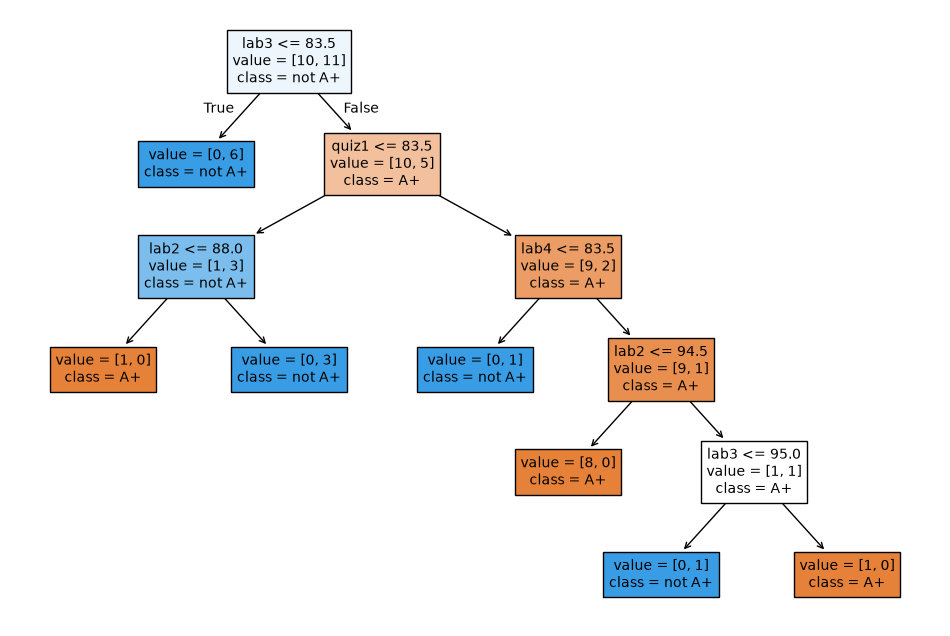

In [37]:
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=10,
)

With the default settings, a decision tree can continue splitting until each leaf contains training examples from only one class, or until another stopping condition is reached. A leaf containing examples from only one class is called **pure** because all the training examples at that leaf have the same target value. For example, a pure leaf in this problem would contain only A+ students or only not-A+ students. 

A very deep tree may create rules that describe only one or two training examples. We can control this behaviour with hyperparameters such as the maximum tree depth.

### A decision stump: `max_depth=1`

A tree with one split is called a **decision stump**.

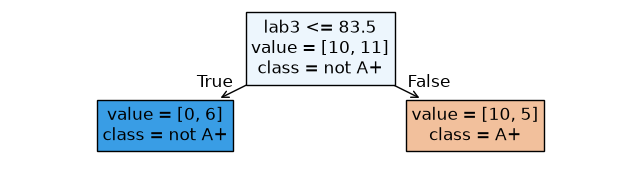

In [38]:
model = DecisionTreeClassifier(max_depth=1, random_state=123)
model.fit(X, y)
width = 8
height = 2
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=12,
)  # custom function defined in code/utils.py

`max_depth` is a **hyperparameter**: a setting chosen before fitting that controls which trees the algorithm is allowed to learn.

### A deeper tree: `max_depth=3`

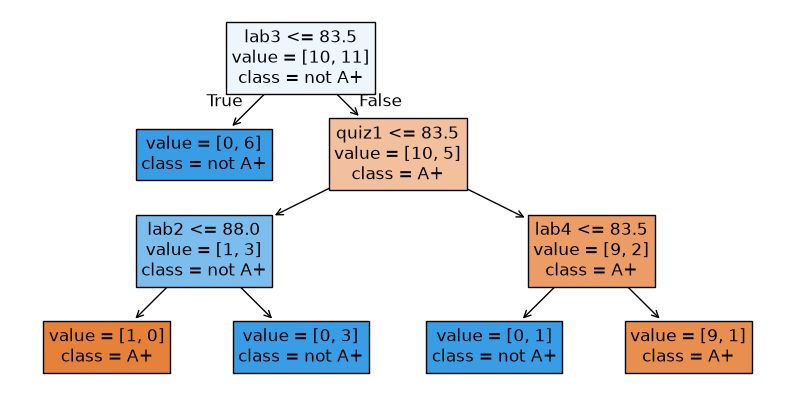

In [39]:
model = DecisionTreeClassifier( 
    random_state=123,
    max_depth=3
)  # Let's try another value for the hyperparameter
model.fit(X, y)
width = 10
height = 5
plt.figure(figsize=(width, height))

custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=12,
)

### Parameters and hyperparameters

**Parameters**
: Values learned from data during `fit` such as split features and thresholds. The fitted model needs them to make predictions.

**Hyperparameters**
: Settings chosen before `fit` that control the learning process or model family. They may be selected using domain knowledge, heuristics, or a systematic validation procedure.

::: {.callout-important}
In `scikit-learn`, hyperparameters are normally supplied when a model is constructed. Fitted parameters are learned later by calling `fit`.
:::

Besides `max_depth`, commonly used decision-tree hyperparameters include `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes`. Each constrains the complexity of the learned tree in a different way.

Use `max_depth` when you want a direct limit on the number of questions along a prediction path. A shallow tree is easier to inspect but may miss useful patterns; a deeper tree can express more detailed rules but may capture peculiarities of the training examples. Higher training accuracy alone cannot settle which depth to use. Chapter 2 introduces ways to compare these choices using data that were not used for fitting.

::: {.callout-tip title="See also"}
See the [`DecisionTreeClassifier` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) for the model's complete interface and hyperparameters.
:::

### Decision boundaries

A fitted classifier partitions the possible feature values into regions assigned to different classes. The border between those regions is its **decision boundary**. With two features, we can draw this boundary and see how model complexity changes it.

A tree diagram shows the sequence of questions. A decision-boundary plot shows the combined effect of those questions across possible inputs. These are two views of the same fitted classifier.

#### Quiz-grade example

For visualization, we fit trees using only `lab4` and `quiz1`.

In [40]:
X_subset = X[["lab4", "quiz1"]]
X_subset.head()

,lab4,quiz1
0,91,92
1,83,91
2,80,80
3,91,89
4,92,85


##### Decision boundary with `max_depth=1`

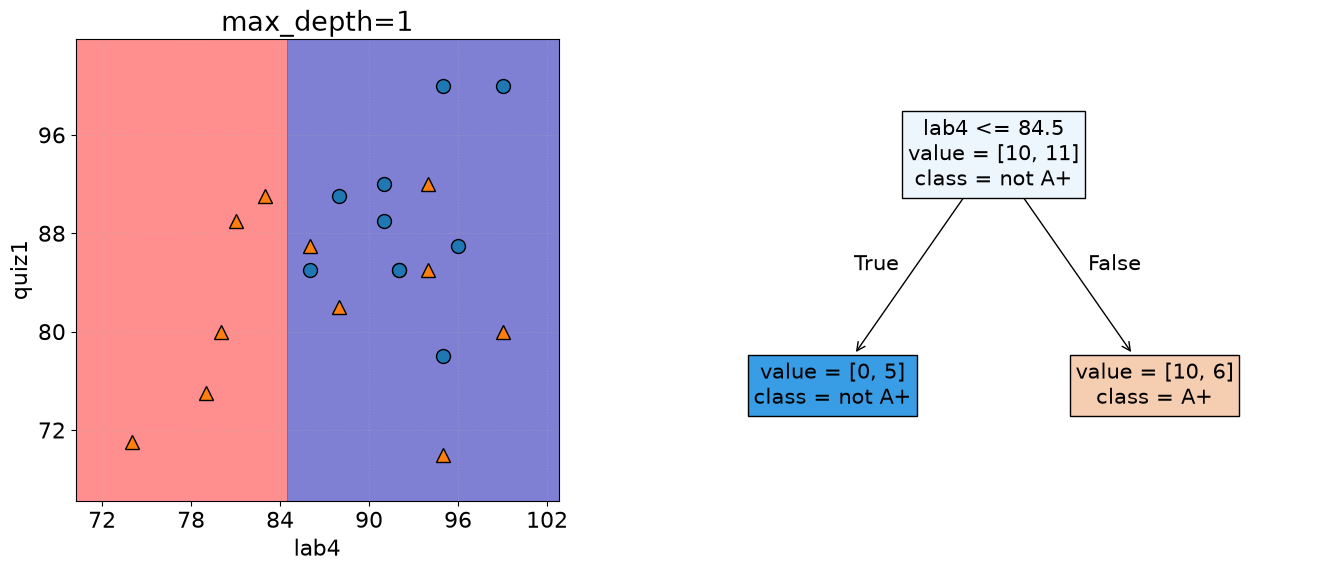

In [41]:
depth = 1  # decision stump
model = DecisionTreeClassifier(max_depth=depth)
model.fit(X_subset.values, y)
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1", fontsize=15
)

The two colored regions show the classes predicted for possible combinations of `lab4` and `quiz1`. A depth-one tree creates a single horizontal or vertical boundary because it asks one threshold question.

##### Decision boundary with `max_depth=2`

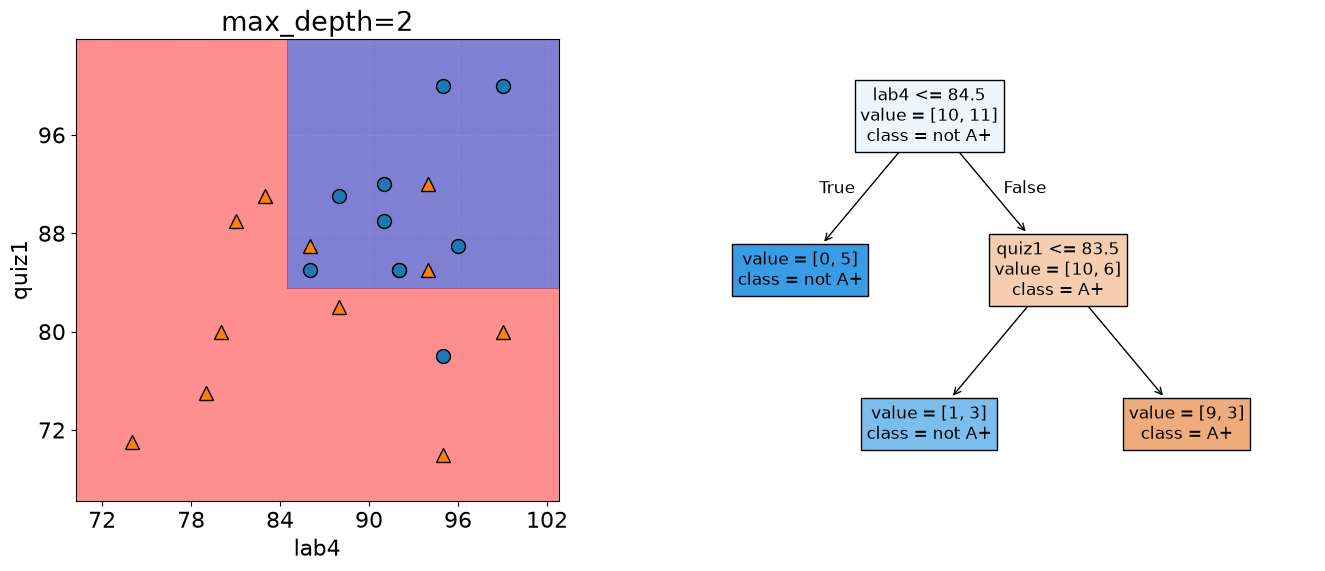

In [42]:
model = DecisionTreeClassifier(max_depth=2)
model.fit(X_subset.values, y)
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1", fontsize=12
)

A second level allows the model to divide another region, producing a more detailed decision boundary.

##### Decision boundary with `max_depth=5`

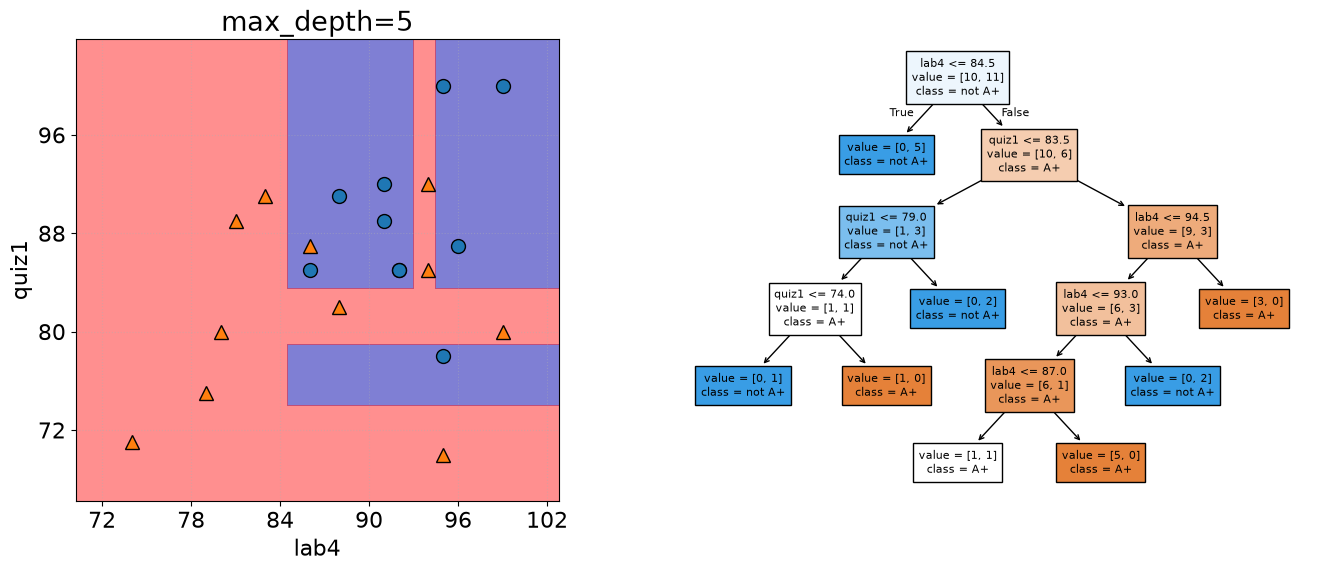

In [43]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_subset.values, y)
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1", fontsize=8
)

At depth five, the boundary follows the training examples much more closely. Greater detail lowers training error, but whether it improves predictions for new examples remains unresolved.

#### Canada–USA cities example

Suppose we observe the longitude, latitude, and country of several cities near the Canada–USA border. Can a decision tree learn a boundary that predicts the country of a new coordinate?

In [44]:
### US Canada cities data
df = pd.read_csv(DATA_DIR / "canada_usa_cities.csv")
df

,longitude,latitude,country
0,-130.0437,55.9773,USA
1,-134.4197,58.3019,USA
2,-123.0780,48.9854,USA
3,-122.7436,48.9881,USA
4,-122.2691,48.9951,USA
...,...,...,...
204,-72.7218,45.3990,Canada
205,-66.6458,45.9664,Canada
206,-79.2506,42.9931,Canada
207,-72.9406,45.6275,Canada


In [45]:
X = df[["longitude", "latitude"]]

In [46]:
y = df["country"]

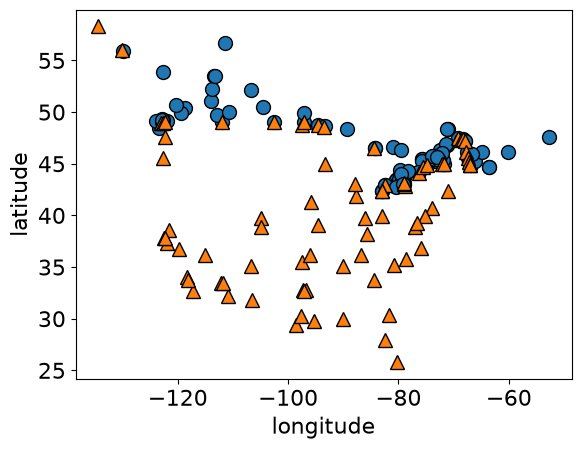

In [47]:
mglearn.discrete_scatter(X.iloc[:, 0], X.iloc[:, 1], y)
plt.xlabel("longitude")
plt.ylabel("latitude");

##### The geographic boundary

In reality, the Canada–USA boundary is known:

![](img/canada-us-border.jpg)

[Image source](https://sovereignlimits.com/blog/u-s-canada-border-history-disputes)

Our model does not receive this boundary. It approximates one using only the limited labeled examples in the training data.

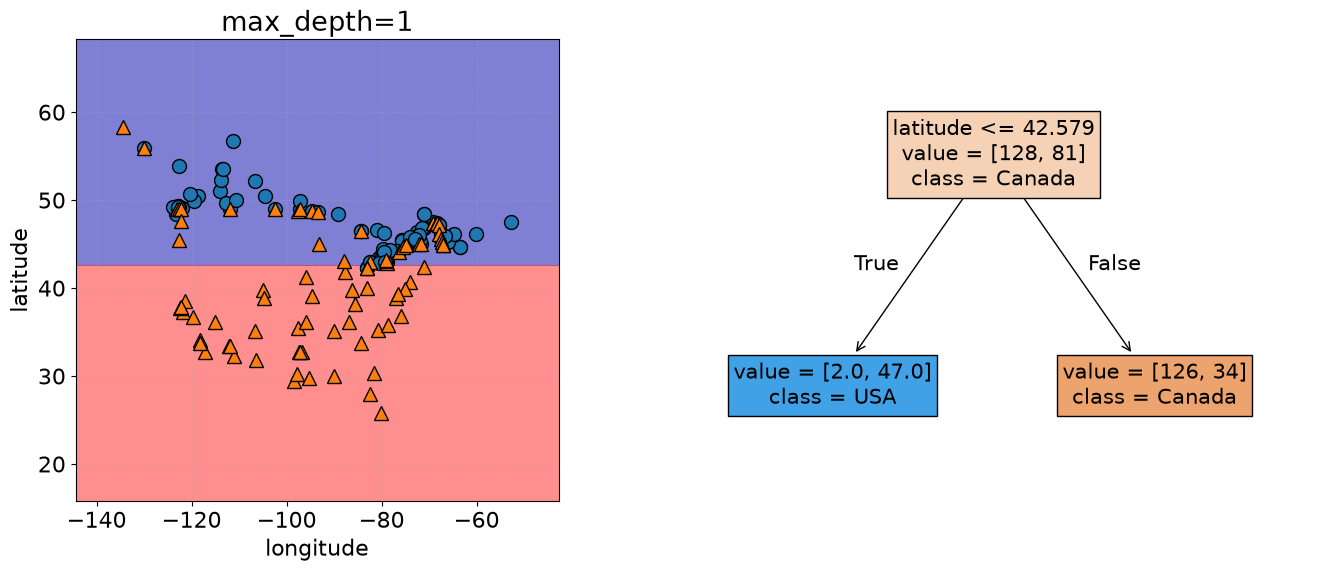

In [48]:
model = DecisionTreeClassifier(max_depth=1)
model.fit(X.values, y)
plot_tree_decision_boundary_and_tree(
    model,
    X,
    y,
    height=6,
    width=16,
    fontsize=15,
    eps=10,
    x_label="longitude",
    y_label="latitude",
)

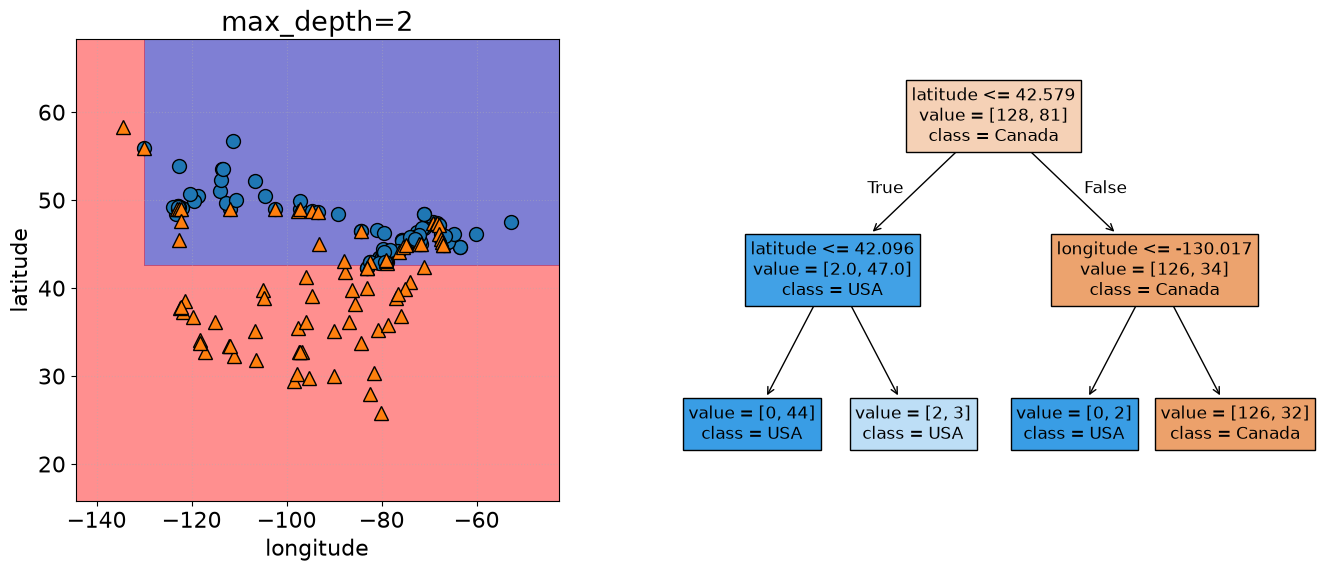

In [49]:
model = DecisionTreeClassifier(max_depth=2)
model.fit(X.values, y)
plot_tree_decision_boundary_and_tree(
    model,
    X,
    y,
    height=6,
    width=16,
    fontsize=12,
    eps=10,
    x_label="longitude",
    y_label="latitude",
)

The city example makes a limitation visible: each tree split uses one coordinate at a time, so its regions have horizontal and vertical edges. More splits can approximate a more detailed border, but the tree only sees the supplied cities. A detailed boundary between those cities is not evidence that it has recovered the true geographic border.

::: {.callout-question}

<div class="exercise-title">Exercise 1.6: Choosing a tree</div>

A depth-one tree and a depth-five tree achieve training accuracies of 70% and 100%, respectively.

1. Which tree would you expect to have a more detailed decision boundary? Explain how its questions create that detail.
2. A colleague proposes choosing the deeper tree because it makes no training errors. What does that result establish, and what remains unknown?
3. If you need to explain a prediction as a short sequence of questions, which tree would you inspect first? What might you give up by limiting depth?

:::

::: {.callout-tip collapse="true" title="Solution"}
The depth-five tree can make more splits along a path, allowing more detailed regions. Its 100% training accuracy establishes that it reproduces the observed training labels; it does not establish how well it predicts new examples. The depth-one tree is a natural starting point for a short explanation, but its single question may miss useful relationships. Choosing a model requires considering both the practical need for a simple explanation and performance on new data.
:::

## Summary

This chapter established the vocabulary and workflow used throughout the book:

- examples are represented by feature rows in $X$, with targets in $y$;
- classification predicts discrete labels, whereas regression predicts numerical values;
- baselines provide reference performance that a useful model should improve upon;
- `scikit-learn` models share the `fit` and `predict` interface, while `score` is model-dependent;
- decision trees learn hierarchies of feature-threshold questions;
- fitted split features and thresholds are parameters, while settings such as `max_depth` are hyperparameters; and
- increasing tree depth creates a more detailed decision boundary and can reduce training error.

::: {.callout-warning title="The question that remains"}
A sufficiently deep tree can classify every training example correctly. Does that mean it will predict new examples well? Chapter 2 introduces data splitting, cross-validation, underfitting, and overfitting to answer this question.
:::